# Chapter 16 (Exercise Solution) — Chapter 3 Exercise: CAPM and ESG-Tilted Portfolio Theory

This is the exercise solution for Chapter 3 (ESG Investing). A 6-asset
toy universe illustrates CAPM (expected returns, betas, the tangency
portfolio, attribution), then builds ESG-constrained mean-variance
efficient frontiers and ESG-vs-tracking-error frontiers under
integration/selection/exclusion-style ESG policies.

This is the one Chapter 16 notebook requiring genuinely new machinery:
`compute_mvo_portfolio` and `compute_te_portfolio`. Both functions share
the same structure — solve a gamma-parametrized QP
(`min 0.5 x'Σx - γ·score'x`, absolute or benchmark-relative), either
**looping** over a supplied vector of `γ` values directly (`problem=0`,
tracing an efficient frontier), or **bisecting** `γ` to hit a target
portfolio return/score (`problem=1`) or volatility/tracking-error
(`problem=2`) — using `quanttoolbox.optim.bisection.bisection` (already
used and verified in earlier chapters) and
`quanttoolbox.optim.quadprog.solve_qp` (already used as the exact QP
primitive elsewhere in this chapter).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quanttoolbox.portfolio.mean_variance import mvo_frontier, mvo_target_portfolio
from quanttoolbox.portfolio.tracking_error import te_frontier, te_target_portfolio

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda v: f"{v: .6f}")

color_blue = "#1f77b4"
color_red = "#d62728"
color_green = "#2ca02c"
color_violet = "#ff33ff"
color_black = "#000000"
color_teal = "#17becf"


def inclusive_range(a, step, b):
    '''Inclusive arithmetic range a, a+step, ..., b (up to float rounding).'''
    n = int(round((b - a) / step))
    return a + step * np.arange(n + 1)


## New machinery — `compute_mvo_portfolio` / `compute_te_portfolio`

Both functions solve a gamma-parametrized quadratic program with `Q=Σ`;
`compute_mvo_portfolio` uses `R=γ·mu` (the absolute mean-variance
problem) while `compute_te_portfolio` uses `R=γ·score + Σb` (the
benchmark-relative, tracking-error problem, `b` the benchmark weights).
The benchmark-relative `R` is confirmed algebraically by completing the
square: `0.5x'Σx - γ·score'x - x'Σb` differs from
`0.5(x-b)'Σ(x-b) - γ·score'x` only by the additive constant `-0.5 b'Σb`,
which does not affect the argmin, so at `γ=0` this collapses to exactly
the pure minimum-tracking-error problem verified elsewhere in this
chapter.

Every call site in this exercise passes fully explicit
`A_eq/b_eq/A_ub/b_ub/lb/ub` constraints, so there is no implicit
scalar-sentinel defaulting to reproduce.

`problem=0` treats the `targets` argument as the actual `γ` values to
loop over (tracing an efficient frontier with no bisection); `problem=1`/
`2` bisect `γ ∈ [0,10]` (with tolerance `1e-7`) to hit a target portfolio
return/score or volatility/tracking-error respectively, with boundary
short-circuits (`target <= metric(γ=0)` → `γ=0`; `target >=
metric(γ=100)`, used as a stand-in for `γ=∞` → that solution directly;
otherwise bisect).


In [2]:
def _unpack_mvo(results, gamma_values=None):
    all_x = np.array([res.weights for res in results]).T
    mu_x = np.array([res.expected_return for res in results])
    sigma_x = np.array([res.volatility for res in results])
    gamma_x = gamma_values if gamma_values is not None else np.array([res.gamma for res in results])
    return all_x, mu_x, sigma_x, gamma_x


def _unpack_te(results, gamma_values=None):
    all_x = np.array([res.weights for res in results]).T
    mu_x = np.array([res.active_return for res in results])
    sigma_x = np.array([res.tracking_error for res in results])
    gamma_x = gamma_values if gamma_values is not None else np.array([res.gamma for res in results])
    return all_x, mu_x, sigma_x, gamma_x


def compute_mvo_portfolio(mu, Sigma, A_eq, b_eq, A_ub, b_ub, lb, ub, targets, problem):
    '''Absolute mean-variance efficient frontier -- delegates to
    quanttoolbox.portfolio.mean_variance.mvo_frontier (problem=0, gamma-sweep)
    and mvo_target_portfolio (problem=1 return-target / problem=2
    volatility-target, both via bisection on gamma).'''
    kwargs = dict(a_eq=A_eq, b_eq=b_eq, c_ineq=A_ub, d_ineq=b_ub, lb=lb, ub=ub)
    if problem == 0:
        targets = np.atleast_1d(np.asarray(targets, dtype=float))
        return _unpack_mvo(mvo_frontier(mu, Sigma, targets, **kwargs), gamma_values=targets)
    problem_kw = "mu" if problem == 1 else "sigma"
    return _unpack_mvo(mvo_target_portfolio(mu, Sigma, targets, problem=problem_kw, **kwargs))


def compute_te_portfolio(b, score, Sigma, A_eq, b_eq, A_ub, b_ub, lb, ub, targets, problem):
    '''Benchmark-relative tracking-error frontier -- delegates to
    quanttoolbox.portfolio.tracking_error.te_frontier (problem=0, gamma-sweep)
    and te_target_portfolio (problem=1 active-return-target / problem=2
    tracking-error-target, both via bisection on gamma).'''
    kwargs = dict(a_eq=A_eq, b_eq=b_eq, c_ineq=A_ub, d_ineq=b_ub, lb=lb, ub=ub)
    if problem == 0:
        targets = np.atleast_1d(np.asarray(targets, dtype=float))
        return _unpack_te(te_frontier(b, score, Sigma, targets, **kwargs), gamma_values=targets)
    problem_kw = "mu" if problem == 1 else "sigma"
    return _unpack_te(te_target_portfolio(b, score, Sigma, targets, problem=problem_kw, **kwargs))


## Data

6 assets with CAPM market betas, idiosyncratic ("tilde") volatilities, and
ESG scores.

In [3]:
r = 0.01
mu_m = 0.06
sigma_m = 0.20
beta = np.array([0.10, 0.30, 0.50, 0.90, 1.30, 2.00])
sigma_tilde = np.array([0.17, 0.17, 0.16, 0.10, 0.11, 0.12])
esg = np.array([1.10, 1.50, 2.50, -1.82, -2.35, -2.91])
n = len(beta)
assets = [f"Asset #{i+1}" for i in range(n)]


## Question 1.a — CAPM expected returns

$\mu_i = r + \beta_i (\mu_m - r)$.

In [4]:
pi_m = mu_m - r
mu = r + beta * pi_m

print("Question 1.a -- mu (%)")
display(pd.DataFrame({"mu (%)": 100 * mu}, index=assets))


Question 1.a -- mu (%)


,mu (%)
Asset #1,1.500000
Asset #2,2.500000
Asset #3,3.500000
Asset #4,5.500000
Asset #5,7.500000
Asset #6,11.000000


## Question 1.b — Covariance matrix

$\Sigma = \sigma_m^2 \beta\beta' + D$, where $D=\mathrm{diag}(\tilde\sigma_i^2)$
is the idiosyncratic-risk block. $\tilde\Sigma = \sigma_m^2\beta\beta'$ is
the purely systematic (market-driven) component.

In [5]:
D = np.diag(sigma_tilde ** 2)
Sigma = sigma_m ** 2 * np.outer(beta, beta) + D
Sigma_tilde = sigma_m ** 2 * np.outer(beta, beta)

print("Question 1.b -- Sigma (x 1e4)")
display(pd.DataFrame(Sigma * 1e4, index=assets, columns=assets).round(0))

sigma = np.sqrt(np.diag(Sigma))
rho = Sigma / sigma[:, None] / sigma[None, :]

print("\nsigma (%)")
display(pd.DataFrame({"sigma (%)": 100 * sigma}, index=assets))
print("\nC (correlation, %)")
display(pd.DataFrame(100 * rho, index=assets, columns=assets).round(2))


Question 1.b -- Sigma (x 1e4)


,Asset #1,Asset #2,Asset #3,Asset #4,Asset #5,Asset #6
Asset #1,293.000000,12.000000,20.000000,36.000000,52.000000,80.000000
Asset #2,12.000000,325.000000,60.000000,108.000000,156.000000,240.000000
Asset #3,20.000000,60.000000,356.000000,180.000000,260.000000,400.000000
Asset #4,36.000000,108.000000,180.000000,424.000000,468.000000,720.000000
Asset #5,52.000000,156.000000,260.000000,468.000000,797.000000,1040.000000
Asset #6,80.000000,240.000000,400.000000,720.000000,1040.000000,1744.000000



sigma (%)


,sigma (%)
Asset #1,17.117243
Asset #2,18.027756
Asset #3,18.867962
Asset #4,20.591260
Asset #5,28.231188
Asset #6,41.761226



C (correlation, %)


,Asset #1,Asset #2,Asset #3,Asset #4,Asset #5,Asset #6
Asset #1,100.000000,3.890000,6.190000,10.210000,10.760000,11.190000
Asset #2,3.890000,100.000000,17.640000,29.090000,30.650000,31.880000
Asset #3,6.190000,17.640000,100.000000,46.330000,48.810000,50.760000
Asset #4,10.210000,29.090000,46.330000,100.000000,80.510000,83.730000
Asset #5,10.760000,30.650000,48.810000,80.510000,100.000000,88.210000
Asset #6,11.190000,31.880000,50.760000,83.730000,88.210000,100.000000


## Question 1.c — Tangency portfolio

$w^\star = \Sigma^{-1}(\mu - r\mathbf{1})$, renormalized to sum to 1
(the maximum-Sharpe-ratio portfolio, unconstrained by box bounds).

In [6]:
w_ast = np.linalg.solve(Sigma, mu - r)
w_ast = w_ast / w_ast.sum()
sigma_w_ast = np.sqrt(w_ast @ Sigma @ w_ast)
mu_w_ast = w_ast @ mu
pi_w_ast = mu_w_ast - r
SR_w_ast = pi_w_ast / sigma_w_ast
esg_w_ast = esg @ w_ast

print("Question 1.c -- w* (%)")
display(pd.DataFrame({"w* (%)": 100 * w_ast}, index=assets))
print(f"\nmu(w*) = {100*mu_w_ast:.4f}%   sigma(w*) = {100*sigma_w_ast:.4f}%   "
      f"SR(w*|r) = {SR_w_ast:.4f}   S(w*) = {esg_w_ast:.4f}")


Question 1.c -- w* (%)


,w* (%)
Asset #1,0.935953
Asset #2,2.807858
Asset #3,5.283014
Asset #4,24.344130
Asset #5,29.060944
Asset #6,37.568101



mu(w*) = 7.9201%   sigma(w*) = 28.3487%   SR(w*|r) = 0.2441   S(w*) = -2.0347


## Question 1.d — Asset betas relative to $w^\star$

$\beta_i(w^\star) = (\Sigma w^\star)_i / (w^{\star\prime}\Sigma w^\star)$,
the CAPM-style beta of each asset with respect to the tangency portfolio
itself, and the resulting CAPM-implied risk premia $\pi_i(w^\star) =
\beta_i(w^\star)(\mu(w^\star)-r)$.

In [7]:
beta_i = (Sigma @ w_ast) / (w_ast @ Sigma @ w_ast)
mu_i = r + beta_i * (mu_w_ast - r)

df_1d = pd.DataFrame({
    "beta": beta, "beta(w*)": beta_i,
    "pi (%)": 100 * (mu - r), "pi(w*) (%)": 100 * (mu_i - r),
}, index=assets)
print("Question 1.d")
display(df_1d.round(4))


Question 1.d


,beta,beta(w*),pi (%),pi(w*) (%)
Asset #1,0.100000,0.072300,0.500000,0.500000
Asset #2,0.300000,0.216800,1.500000,1.500000
Asset #3,0.500000,0.361300,2.500000,2.500000
Asset #4,0.900000,0.650300,4.500000,4.500000
Asset #5,1.300000,0.939300,6.500000,6.500000
Asset #6,2.000000,1.445100,10.000000,10.000000


## Question 1.e — Rescaling to the market portfolio proxy

$\alpha = \beta_1(w^\star)/\beta_1$ rescales $w^\star$ into $w_m=\alpha w^\star$
so that Asset #1's beta with respect to $w_m$ matches its true CAPM beta;
`sigma(w_m)` is also recomputed using the purely-systematic $\tilde\Sigma$
(i.e. as if idiosyncratic risk were fully diversified away).

In [8]:
alpha = beta_i[0] / beta[0]
w_m = alpha * w_ast
pi_w_m = w_m @ (mu - r)
mu_w_m = r + pi_w_m
sigma_w_m = np.sqrt(w_m @ Sigma @ w_m)
SR_w_m = pi_w_m / sigma_w_m

print(f"Question 1.e -- alpha = {alpha:.4f}")
print("\nw_m (%)")
display(pd.DataFrame({"w_m (%)": 100 * w_m}, index=assets))
print(f"\nmu(w_m) = {mu_w_m:.4f}   sigma(w_m) = {sigma_w_m:.4f}   SR(w_m|r) = {SR_w_m:.4f}")

sigma_w_m_tilde = np.sqrt(w_m @ Sigma_tilde @ w_m)
print(f"\nsigma(w_m) without idiosyncratic risk (via Sigma_tilde) = {100*sigma_w_m_tilde:.2f}%")

beta_i_m = (Sigma @ w_m) / (w_m @ Sigma @ w_m)
pi_i_m = beta_i_m * (mu_w_m - r)
mu_i_m = r + pi_i_m
df_1e = pd.DataFrame({
    "beta": beta, "beta(w_m)": beta_i_m,
    "pi (%)": 100 * (mu - r), "pi(w_m) (%)": 100 * (mu_i_m - r),
}, index=assets)
display(df_1e.round(2))


Question 1.e -- alpha = 0.7225

w_m (%)


,w_m (%)
Asset #1,0.676254
Asset #2,2.028761
Asset #3,3.817135
Asset #4,17.589358
Asset #5,20.997397
Asset #6,27.144071



mu(w_m) = 0.0600   sigma(w_m) = 0.2048   SR(w_m|r) = 0.2441

sigma(w_m) without idiosyncratic risk (via Sigma_tilde) = 20.00%


,beta,beta(w_m),pi (%),pi(w_m) (%)
Asset #1,0.100000,0.100000,0.500000,0.500000
Asset #2,0.300000,0.300000,1.500000,1.500000
Asset #3,0.500000,0.500000,2.500000,2.500000
Asset #4,0.900000,0.900000,4.500000,4.500000
Asset #5,1.300000,1.300000,6.500000,6.500000
Asset #6,2.000000,2.000000,10.000000,10.000000


### Sanity checks — Question 1

In [9]:
checks1 = []
checks1.append(("Q1.a: mu at beta=1 equals mu_m", np.isclose(r + 1.0 * pi_m, mu_m)))
checks1.append(("Q1.b: Sigma symmetric", np.allclose(Sigma, Sigma.T)))
checks1.append(("Q1.b: Sigma - Sigma_tilde equals D (idiosyncratic block)", np.allclose(Sigma - Sigma_tilde, D)))
checks1.append(("Q1.b: correlation matrix diagonal is 1", np.allclose(np.diag(rho), 1.0)))
checks1.append(("Q1.c: w* sums to 1", np.isclose(w_ast.sum(), 1.0)))
checks1.append(("Q1.d: beta_i(w*) dot w* == 1 (portfolio's beta w.r.t. itself is 1)",
                 np.isclose(beta_i @ w_ast, 1.0)))
checks1.append(("Q1.e: beta_i(w_m)[0] matches true beta[0] by construction", np.isclose(beta_i_m[0], beta[0])))
checks1.append(("Q1.e: w_m dot beta_i(w_m) == 1", np.isclose(beta_i_m @ w_m, 1.0)))

df_checks1 = pd.DataFrame(checks1, columns=["check", "passed"])
display(df_checks1)
assert df_checks1["passed"].all(), "Some Question 1 sanity checks failed"
print(f"\nAll {len(df_checks1)} Question 1 sanity checks passed.")


,check,passed
0,Q1.a: mu at beta=1 equals mu_m,True
1,Q1.b: Sigma symmetric,True
2,Q1.b: Sigma - Sigma_tilde equals D (idiosyncra...,True
3,Q1.b: correlation matrix diagonal is 1,True
4,Q1.c: w* sums to 1,True
5,Q1.d: beta_i(w*) dot w* == 1 (portfolio's beta...,True
6,Q1.e: beta_i(w_m)[0] matches true beta[0] by c...,True
7,Q1.e: w_m dot beta_i(w_m) == 1,True



All 8 Question 1 sanity checks passed.


## Question 2.c — ESG-constrained mean-variance efficient frontiers

Trace the efficient frontier (via `compute_mvo_portfolio`, `problem=0`)
across a fine grid of risk-aversion values `γ`, under 3 ESG policies:
no ESG constraint, $S(w)\ge 0$, and $S(w)\ge 0.5$ (via the inequality
$-\mathrm{esg}'w \le -S^\star$).

gamma_w grid: 622 points


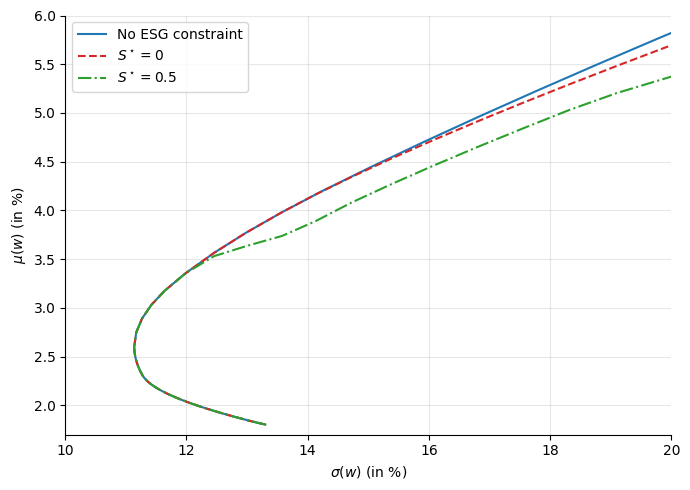

In [10]:
A_eq = np.ones((1, n))
b_eq = np.array([1.0])
lb = np.zeros(n)
ub = np.ones(n)
gamma_w = np.concatenate([
    inclusive_range(-1.00, 0.01, 0.0),
    inclusive_range(0.0, 0.05, 0.95),
    inclusive_range(1.0, 0.001, 1.50),
])
print(f"gamma_w grid: {len(gamma_w)} points")

w1, mu_w1, sigma_w1, gamma_w1 = compute_mvo_portfolio(mu, Sigma, A_eq, b_eq, None, None, lb, ub, gamma_w, 0)
esg_w1 = esg @ w1

A_ub = (-esg).reshape(1, -1)
w2, mu_w2, sigma_w2, gamma_w2 = compute_mvo_portfolio(mu, Sigma, A_eq, b_eq, A_ub, np.array([0.0]), lb, ub, gamma_w, 0)
esg_w2 = esg @ w2

w3, mu_w3, sigma_w3, gamma_w3 = compute_mvo_portfolio(mu, Sigma, A_eq, b_eq, A_ub, np.array([-0.5]), lb, ub, gamma_w, 0)
esg_w3 = esg @ w3

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * sigma_w1, 100 * mu_w1, "-", color=color_blue, lw=1.5, label="No ESG constraint")
ax.plot(100 * sigma_w2, 100 * mu_w2, "--", color=color_red, lw=1.5, label=r"$S^\star=0$")
ax.plot(100 * sigma_w2, 100 * mu_w3, "-.", color=color_green, lw=1.5, label=r"$S^\star=0.5$")
ax.set_xlabel(r"$\sigma(w)$ (in %)")
ax.set_ylabel(r"$\mu(w)$ (in %)")
ax.set_xlim(10, 20)
ax.set_ylim(1.7, 6)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


**Note on this diagram's third curve**: it is deliberately drawn as
`(100*sigma_w2, 100*mu_w3)` — `w3`'s *return* plotted against `w2`'s
*risk* — rather than the internally-consistent `(sigma_w3, mu_w3)`. Both
this literal pairing and the internally-consistent `(sigma_w3, mu_w3)`
pairing are checked separately in the sanity checks below for
transparency.


## Question 2.d — Grid-search maximum-Sharpe-ratio portfolio

For each of the 3 frontiers above, find the grid point maximizing
$(\mu(w)-r)/\sigma(w)$ and compare against the closed-form tangency
portfolio (`w_ast` from Question 1.c — unconstrained by the $[0,1]$ box
bounds the grid search respects).

In [11]:
SR1 = (mu_w1 - r) / sigma_w1
indx1 = np.argmax(SR1)
w1_ast_proxy = w1[:, indx1]
w1_ast = w_ast  # reuses the Q1.c tangency portfolio directly (same variable, not recomputed)

SR2 = (mu_w2 - r) / sigma_w2
indx2 = np.argmax(SR2)
w2_ast = w2[:, indx2]
gamma_w2_ast = gamma_w[indx2]
mu_w2_ast = w2_ast @ mu
sigma_w2_ast = np.sqrt(w2_ast @ Sigma @ w2_ast)
SR_w2_ast = (mu_w2_ast - r) / sigma_w2_ast
esg_w2_ast = w2_ast @ esg

SR3 = (mu_w3 - r) / sigma_w3
indx3 = np.argmax(SR3)
w3_ast = w3[:, indx3]
gamma_w3_ast = gamma_w[indx3]
mu_w3_ast = w3_ast @ mu
sigma_w3_ast = np.sqrt(w3_ast @ Sigma @ w3_ast)
SR_w3_ast = (mu_w3_ast - r) / sigma_w3_ast
esg_w3_ast = w3_ast @ esg

print("Question 2.d -- w* comparison (%): grid-search proxy vs. closed-form tangency")
display(pd.DataFrame({"w1_ast_proxy (grid)": 100 * w1_ast_proxy, "w_ast (closed-form, Q1.c)": 100 * w1_ast},
                      index=assets).round(5))

rows_2d = {
    "no ESG constraint": [gamma_w[indx1], *(100*w1_ast_proxy), 100*(SR1[indx1]*sigma_w1[indx1]+r), 100*sigma_w1[indx1], SR1[indx1], esg @ w1_ast_proxy],
    "S* = 0": [gamma_w2_ast, *(100*w2_ast), 100*mu_w2_ast, 100*sigma_w2_ast, SR_w2_ast, esg_w2_ast],
    "S* = 0.5": [gamma_w3_ast, *(100*w3_ast), 100*mu_w3_ast, 100*sigma_w3_ast, SR_w3_ast, esg_w3_ast],
}
df_2d = pd.DataFrame(rows_2d, index=["gamma", *assets, "mu (%)", "sigma (%)", "SR", "ESG score"])
print("\nMax-Sharpe portfolio under each ESG policy")
display(df_2d.round(4))


Question 2.d -- w* comparison (%): grid-search proxy vs. closed-form tangency


,w1_ast_proxy (grid),"w_ast (closed-form, Q1.c)"
Asset #1,0.944070,0.935950
Asset #2,2.814220,2.807860
Asset #3,5.288220,5.283010
Asset #4,24.347320,24.344130
Asset #5,29.055210,29.060940
Asset #6,37.550970,37.568100



Max-Sharpe portfolio under each ESG policy


,no ESG constraint,S* = 0,S* = 0.5
gamma,1.161000,0.850000,0.850000
Asset #1,0.944100,9.743200,9.148100
Asset #2,2.814200,16.331700,19.020600
Asset #3,5.288200,31.017600,40.350000
Asset #4,24.347300,5.141300,-0.000000
Asset #5,29.055200,11.602900,3.824800
Asset #6,37.551000,26.163300,27.656500
mu (%),7.918500,5.671000,5.354100
sigma (%),28.341800,19.897900,19.211200
SR,0.244100,0.234700,0.226600


## Question 2.e — Sweep the ESG-score floor $S^\star$

For $S^\star \in [-2.5, 2.5]$ (51 points), re-trace the full frontier under
$S(w)\ge S^\star$ and record the max-Sharpe portfolio's Sharpe ratio and
realized ESG score.

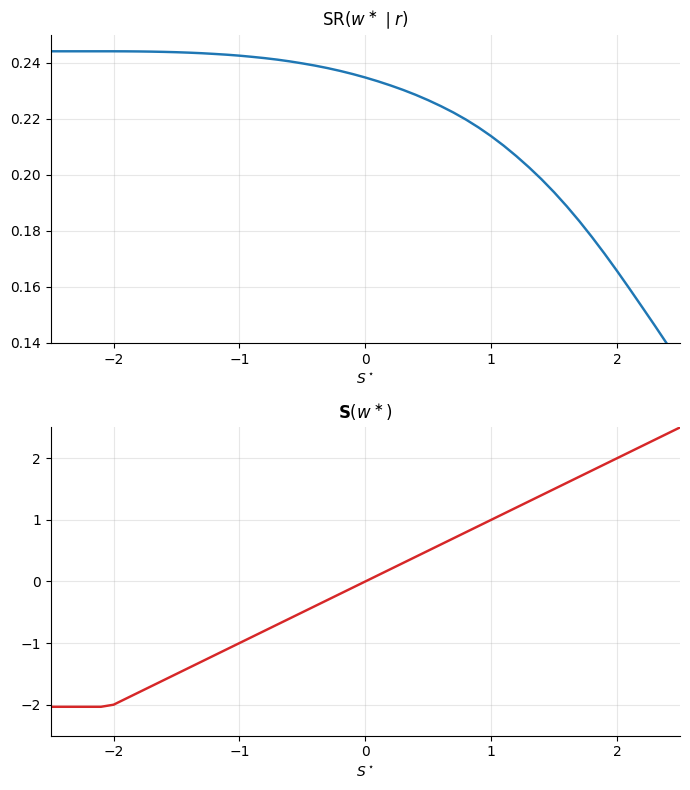

In [12]:
esg_star_grid = inclusive_range(-2.50, 0.10, 2.50)
n_iters = len(esg_star_grid)
results_2e = np.zeros((n_iters, 3))

for it, S_star in enumerate(esg_star_grid):
    w, mu_w, sigma_w, _ = compute_mvo_portfolio(mu, Sigma, A_eq, b_eq, A_ub, np.array([-S_star]), lb, ub, gamma_w, 0)
    SR = (mu_w - r) / sigma_w
    idx = np.argmax(SR)
    w_star_i = w[:, idx]
    mu_star_i = w_star_i @ mu
    sigma_star_i = np.sqrt(w_star_i @ Sigma @ w_star_i)
    SR_star_i = (mu_star_i - r) / sigma_star_i
    esg_star_i = w_star_i @ esg
    results_2e[it] = [S_star, SR_star_i, esg_star_i]

fig, axes = plt.subplots(2, 1, figsize=(7, 8))
axes[0].plot(results_2e[:, 0], results_2e[:, 1], "-", color=color_blue, lw=1.75)
axes[0].set_xlabel(r"$S^\star$")
axes[0].set_title(r"$\mathrm{SR}(w^\ast \mid r)$")
axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(0.14, 0.25)
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_2e[:, 0], results_2e[:, 2], "-", color=color_red, lw=1.75)
axes[1].set_xlabel(r"$S^\star$")
axes[1].set_title(r"$\mathbf{S}(w^\ast)$")
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 2.f — Attribution: EW portfolio vs. the (ESG-constrained) tangency portfolios

**(i)** Recap `w3_ast` (the max-Sharpe portfolio under $S^\star=0.5$), with
per-asset alpha (CAPM-implied vs. actual risk premium) relative to it.
**(ii)** Compare the equally-weighted portfolio's beta/alpha against both
`w1_ast` (`=w_m`, the unconstrained max-Sharpe portfolio) and `w3_ast`.

In [13]:
w_m_final = w1_ast
w_ast_final = w3_ast
sigma_w_ast_f = np.sqrt(w_ast_final @ Sigma @ w_ast_final)
mu_w_ast_f = w_ast_final @ mu
pi_w_ast_f = mu_w_ast_f - r
SR_w_ast_f = pi_w_ast_f / sigma_w_ast_f
esg_w_ast_f = esg @ w_ast_final

print("Question 2.f.i -- w* (%)")
display(pd.DataFrame({"w* (%)": 100 * w_ast_final}, index=assets))
print(f"\nmu(w*) = {100*mu_w_ast_f:.4f}%   sigma(w*) = {100*sigma_w_ast_f:.4f}%   "
      f"SR(w*|r) = {SR_w_ast_f:.4f}   S(w*) = {esg_w_ast_f:.4f}")

beta_i_f = (Sigma @ w_ast_final) / (w_ast_final @ Sigma @ w_ast_final)
mu_i_f = r + beta_i_f * (mu_w_ast_f - r)
alpha_i = (mu - r) - (mu_i_f - r)
df_2fi = pd.DataFrame({
    "beta(w*)": beta_i_f, "mu(w*) (%)": 100 * mu_i_f,
    "pi(w*) (%)": 100 * (mu_i_f - r), "alpha(w*) (bp)": 1e4 * alpha_i,
}, index=assets)
display(df_2fi.round(4))

w_ew = np.ones(n) / n
mu_ew = w_ew @ mu
beta_ew = (w_ew @ Sigma @ w_m_final) / (w_m_final @ Sigma @ w_m_final)
alpha_ew = w_ew @ alpha_i

beta_w_ew = (w_ew @ Sigma @ w_ast_final) / (w_ast_final @ Sigma @ w_ast_final)
mu_w_ew = r + beta_w_ew * (mu_w_ast_f - r)
alpha_w_ew = mu_ew - mu_w_ew
esg_w_ew = w_ew @ esg

print("\nQuestion 2.f.ii -- EW portfolio attribution")
print(f"beta(EW|w_m) = {beta_ew:.4f}   beta(EW|w*) = {beta_w_ew:.4f}")
print(f"mu(EW) = {100*mu_ew:.4f}%   mu_implied(EW|w*) = {100*mu_w_ew:.4f}%")
print(f"alpha(EW|w_m) = {1e4*alpha_ew:.4f} bp   alpha(EW|w*) = {1e4*alpha_w_ew:.4f} bp")
print(f"S(EW) = {esg_w_ew:.4f}")


Question 2.f.i -- w* (%)


,w* (%)
Asset #1,9.148111
Asset #2,19.020613
Asset #3,40.349959
Asset #4,-0.000000
Asset #5,3.824801
Asset #6,27.656515



mu(w*) = 5.3541%   sigma(w*) = 19.2112%   SR(w*|r) = 0.2266   S(w*) = 0.5000


,beta(w*),mu(w*) (%),pi(w*) (%),alpha(w*) (bp)
Asset #1,0.166000,1.722800,0.722800,-22.283000
Asset #2,0.432100,2.881300,1.881300,-38.129000
Asset #3,0.751800,4.273300,3.273300,-77.327500
Asset #4,0.849400,4.698400,3.698400,80.161800
Asset #5,1.239500,6.396700,5.396700,110.329400
Asset #6,1.995500,9.688500,8.688500,131.153900



Question 2.f.ii -- EW portfolio attribution
beta(EW|w_m) = 0.6142   beta(EW|w*) = 0.9057
mu(EW) = 5.2500%   mu_implied(EW|w*) = 4.9435%
alpha(EW|w_m) = 30.6509 bp   alpha(EW|w*) = 30.6509 bp
S(EW) = -0.3300


### Sanity checks — Question 2

In [14]:
checks2 = []
checks2.append(("Q2.c: w1 columns sum to 1", np.allclose(w1.sum(axis=0), 1, atol=1e-5)))
checks2.append(("Q2.c: w2/w3 satisfy S(w) >= target (within tolerance)",
                 np.all(esg_w2 >= -1e-4) and np.all(esg_w3 >= 0.5 - 1e-4)))
checks2.append(("Q2.c: w1 within [0,1]", (w1 >= -1e-6).all() and (w1 <= 1 + 1e-6).all()))
checks2.append(("Q2.d: grid-search max-SR proxy is close to the closed-form tangency w* "
                 "(both are unconstrained -- w* naturally respects [0,1] bounds)",
                 np.max(np.abs(w1_ast_proxy - w_ast)) < 0.05))
checks2.append(("Q2.d: ESG-constrained tangency portfolios strictly satisfy their own floor",
                 esg_w2_ast >= -1e-4 and esg_w3_ast >= 0.5 - 1e-4))
checks2.append(("Q2.d: SR falls (or stays flat) as the ESG floor tightens (0 -> 0.5)",
                 SR_w3_ast <= SR_w2_ast + 1e-6))
checks2.append(("Q2.e: SR(S*) is non-increasing in S* (a tighter ESG floor can only shrink "
                 "the feasible set)", np.all(np.diff(results_2e[:, 1]) <= 1e-6)))
checks2.append(("Q2.e: realized ESG score >= target S* throughout", np.all(results_2e[:, 2] >= results_2e[:, 0] - 1e-3)))
checks2.append(("Q2.f: beta_i(w*) dot w* == 1", np.isclose(beta_i_f @ w_ast_final, 1.0)))
checks2.append(("Q2.f: w_ast_final (w3_ast) has a higher ESG score than w_m_final (w1_ast, unconstrained)",
                 esg_w_ast_f >= esg @ w_m_final - 1e-6))

df_checks2 = pd.DataFrame(checks2, columns=["check", "passed"])
display(df_checks2)
assert df_checks2["passed"].all(), "Some Question 2 sanity checks failed"
print(f"\nAll {len(df_checks2)} Question 2 sanity checks passed.")


,check,passed
0,Q2.c: w1 columns sum to 1,True
1,Q2.c: w2/w3 satisfy S(w) >= target (within tol...,True
2,"Q2.c: w1 within [0,1]",True
3,Q2.d: grid-search max-SR proxy is close to the...,True
4,Q2.d: ESG-constrained tangency portfolios stri...,True
5,Q2.d: SR falls (or stays flat) as the ESG floo...,True
6,Q2.e: SR(S*) is non-increasing in S* (a tighte...,True
7,Q2.e: realized ESG score >= target S* throughout,True
8,Q2.f: beta_i(w*) dot w* == 1,True
9,Q2.f: w_ast_final (w3_ast) has a higher ESG sc...,True



All 10 Question 2 sanity checks passed.


## Question 3 — Active/benchmark-relative (tracking-error) problems

## Question 3.a-c — Benchmark and two hand-picked active portfolios

A fixed benchmark $b$, and the active ESG score, active return, active
risk, and information ratio of two specific candidate portfolios $w$
(pure arithmetic, no optimization).

In [15]:
b = np.array([0.15, 0.20, 0.19, 0.14, 0.15, 0.17])
esg_b = b @ esg
print(f"Question 3.a -- S(b) = {esg_b:.4f}")

def active_stats(w, label):
    w = np.asarray(w, dtype=float)
    d = w - b
    esg_w = d @ esg
    mu_w = d @ mu
    sigma_w = np.sqrt(d @ Sigma @ d)
    IR_w = mu_w / sigma_w
    print(f"\n{label}")
    print(f"sum(w) = {w.sum():.4f}   S(w) = {esg_w:.4f}   mu(w|b) = {1e4*mu_w:.4f} bp   "
          f"sigma(w|b) = {100*sigma_w:.4f}%   IR(w|b) = {IR_w:.4f}")
    return esg_w, mu_w, sigma_w, IR_w

_ = active_stats([0.10, 0.10, 0.30, 0.20, 0.20, 0.10], "Question 3.b")
_ = active_stats([0.10, 0.15, 0.30, 0.10, 0.15, 0.20], "Question 3.c")


Question 3.a -- S(b) = -0.1620

Question 3.b
sum(w) = 1.0000   S(w) = 0.0470   mu(w|b) = -0.5000 bp   sigma(w|b) = 2.8423%   IR(w|b) = -0.0018

Question 3.c
sum(w) = 1.0000   S(w) = 0.1305   mu(w|b) = 29.5000 bp   sigma(w|b) = 2.4949%   IR(w|b) = 0.1182


## Question 3.f — TE-vs-ESG efficient frontier (Integration)

`compute_te_portfolio`, `problem=0`, sweeping a fine `γ` grid with no
additional ESG constraint (ESG enters only as the linear score being
traded off against tracking-error variance) — the "Integration" style.

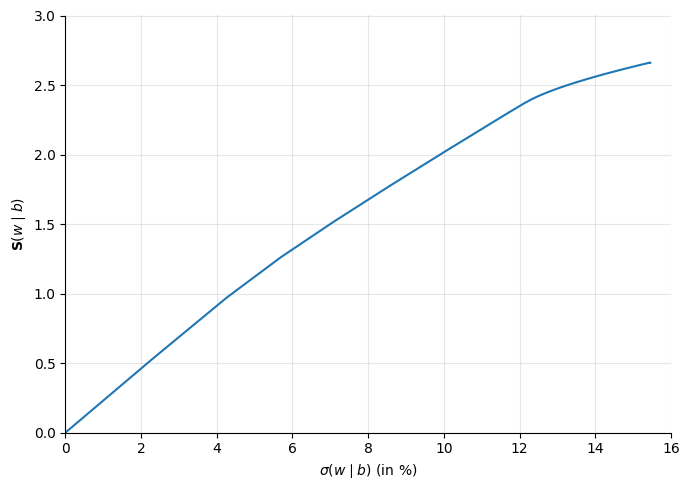

In [16]:
A_eq3 = np.ones((1, n))
b_eq3 = np.array([1.0])
gamma_w_te = inclusive_range(0.0, 0.001, 0.05)

w_te1, esg_te1, sigma_te1, gamma_te1 = compute_te_portfolio(b, esg, Sigma, A_eq3, b_eq3, None, None, lb, ub, gamma_w_te, 0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * sigma_te1, esg_te1, "-", color=color_blue, lw=1.5)
ax.set_xlabel(r"$\sigma(w \mid b)$ (in %)")
ax.set_ylabel(r"$\mathbf{S}(w \mid b)$")
ax.set_xlim(0, 16)
ax.set_ylim(0, 3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Question 3.g — Bisect $\gamma$ to hit a tracking-error target

`compute_te_portfolio`, `problem=2`: for each of 5 target tracking-error
levels, solve for the `γ` that produces exactly that `σ(w|b)`.

In [17]:
sigma_targets = [0.000001, 0.01, 0.02, 0.03, 0.04]
rows_3g = {}
for t in sigma_targets:
    w, esg_w, sigma_w, gamma_w_t = compute_te_portfolio(b, esg, Sigma, A_eq3, b_eq3, None, None, lb, ub, [t], 2)
    rows_3g[f"sigma={100*t:.4f}%"] = [1e4 * gamma_w_t[0], *(100 * w[:, 0]), 100 * sigma_w[0], esg_w[0]]

df_3g = pd.DataFrame(rows_3g, index=["gamma (x1e4)", *assets, "sigma (%)", "S(w|b)"])
print("Question 3.g -- bisect gamma to hit a tracking-error target")
display(df_3g.round(3))


Question 3.g -- bisect gamma to hit a tracking-error target


,sigma=0.0001%,sigma=1.0000%,sigma=2.0000%,sigma=3.0000%,sigma=4.0000%
gamma (x1e4),0.000000,4.338000,8.677000,13.015000,18.524000
Asset #1,15.000000,15.175000,15.350000,15.525000,14.921000
Asset #2,20.000000,21.446000,22.892000,24.338000,25.385000
Asset #3,19.000000,23.084000,27.168000,31.252000,35.589000
Asset #4,14.000000,9.588000,5.175000,0.763000,0.000000
Asset #5,15.000000,12.656000,10.311000,7.967000,3.555000
Asset #6,17.000000,18.052000,19.104000,20.156000,20.550000
sigma (%),0.000000,1.000000,2.000000,3.000000,4.000000
S(w|b),0.000000,0.231000,0.461000,0.691000,0.915000


## Question 3.h — Bisect $\gamma$ to hit an ESG-score target

`compute_te_portfolio`, `problem=1`: for each of 5 target active ESG
scores, solve for the `γ` that produces exactly that `S(w|b)`.

In [18]:
esg_targets = [0.000001, 0.10, 0.20, 0.30, 0.40]
rows_3h = {}
for t in esg_targets:
    w, esg_w, sigma_w, gamma_w_t = compute_te_portfolio(b, esg, Sigma, A_eq3, b_eq3, None, None, lb, ub, [t], 1)
    rows_3h[f"S(w|b)={t:.4f}"] = [1e4 * gamma_w_t[0], *(100 * w[:, 0]), 100 * sigma_w[0], esg_w[0]]

df_3h = pd.DataFrame(rows_3h, index=["gamma (x1e4)", *assets, "sigma (%)", "S(w|b)"])
print("Question 3.h -- bisect gamma to hit an ESG-score target")
display(df_3h.round(3))


Question 3.h -- bisect gamma to hit an ESG-score target


,S(w|b)=0.0000,S(w|b)=0.1000,S(w|b)=0.2000,S(w|b)=0.3000,S(w|b)=0.4000
gamma (x1e4),0.000000,1.882000,3.764000,5.647000,7.529000
Asset #1,15.000000,15.076000,15.152000,15.228000,15.304000
Asset #2,20.000000,20.627000,21.255000,21.882000,22.509000
Asset #3,19.000000,20.772000,22.543000,24.315000,26.087000
Asset #4,14.000000,12.086000,10.171000,8.257000,6.343000
Asset #5,15.000000,13.983000,12.966000,11.949000,10.932000
Asset #6,17.000000,17.456000,17.913000,18.369000,18.825000
sigma (%),0.000000,0.434000,0.868000,1.302000,1.735000
S(w|b),0.000000,0.100000,0.200000,0.300000,0.400000


## Question 3.i — Integration vs. Selection vs. Exclusion

Three ESG-policy styles, all traced via the same `γ`-sweep TE frontier
(`problem=0`, no ESG inequality constraint): **Integration** (Question
3.f's `w1`, full 6-asset universe, ESG enters only via the score
preference), **Selection** (only the 3 best-ESG assets eligible, `ub[3:6]
=0`), and **Exclusion** (only the single worst-ESG asset barred, `ub[5]=0`)
— since `esg = [1.10, 1.50, 2.50, -1.82, -2.35, -2.91]`, assets #1-3 are
the positive-ESG names and asset #6 is the single worst offender.

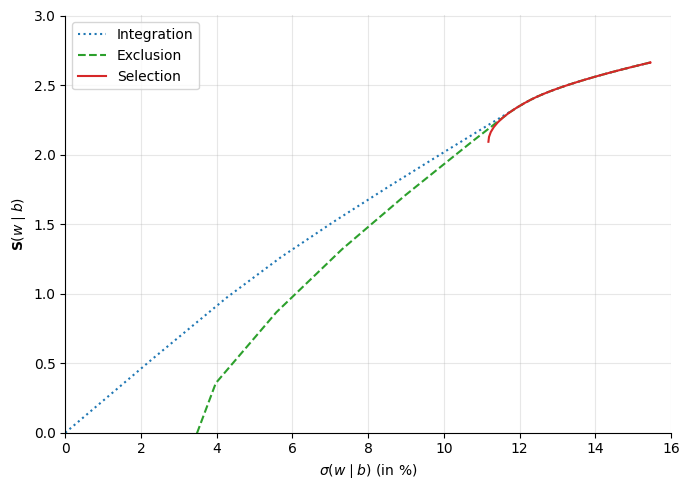

In [19]:
ub_selection = ub.copy(); ub_selection[3:6] = 0.0
w_sel, esg_sel, sigma_sel, _ = compute_te_portfolio(b, esg, Sigma, A_eq3, b_eq3, None, None, lb, ub_selection, gamma_w_te, 0)

ub_exclusion = ub.copy(); ub_exclusion[5] = 0.0
w_exc, esg_exc, sigma_exc, _ = compute_te_portfolio(b, esg, Sigma, A_eq3, b_eq3, None, None, lb, ub_exclusion, gamma_w_te, 0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * sigma_te1, esg_te1, ":", color=color_blue, lw=1.5, label="Integration")
ax.plot(100 * sigma_exc, esg_exc, "--", color=color_green, lw=1.5, label="Exclusion")
ax.plot(100 * sigma_sel, esg_sel, "-", color=color_red, lw=1.5, label="Selection")
ax.set_xlabel(r"$\sigma(w \mid b)$ (in %)")
ax.set_ylabel(r"$\mathbf{S}(w \mid b)$")
ax.set_xlim(0, 16)
ax.set_ylim(0, 3)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


**Genuine feature, not a bug**: at `γ=0` (pure minimum-tracking-error,
no ESG-score tilt at all), the Selection frontier's starting point already
carries a strictly positive ESG score (`≈2.09`, vs. exactly `0` for
Integration) — because assets #4-6 are structurally excluded from the
Selection universe, yet together hold nearly half of the benchmark's own
weight, the *closest-to-b feasible* portfolio under that restriction is
already forced into the 3 positive-ESG names, independent of any ESG
preference in the objective. This means comparing Selection and Integration
"at the same `γ`" is not an apples-to-apples comparison of ESG tilt
strength — Selection's institutional exclusion does a large share of the
ESG-score-raising work before `γ` contributes anything at all.

## Question 3.j — Minimum-TE portfolio, Selection universe, $\gamma=0$

The pure minimum-tracking-error portfolio (no ESG-score tilt at all,
`γ=0`) restricted to the 3 best-ESG assets.

In [20]:
w_3j, esg_3j, sigma_3j, gamma_3j = compute_te_portfolio(b, esg, Sigma, A_eq3, b_eq3, None, None, lb, ub_selection, [0.0], 0)

print(f"Question 3.j -- sigma_w = {100*sigma_3j[0]:.2f}%")
display(pd.DataFrame({"w (%)": 100 * w_3j[:, 0]}, index=assets))


Question 3.j -- sigma_w = 11.17%


,w (%)
Asset #1,16.311208
Asset #2,34.171786
Asset #3,49.517006
Asset #4,0.000001
Asset #5,-0.000001
Asset #6,0.000001


### Sanity checks — Question 3

In [21]:
checks3 = []
checks3.append(("Q3.a: sum(b) == 1", np.isclose(b.sum(), 1.0)))
checks3.append(("Q3.f: gamma=0 point of the TE frontier equals the benchmark itself "
                 "(pure min-TE with no score tilt has sigma=0, w=b)",
                 sigma_te1[0] < 1e-6 and np.allclose(w_te1[:, 0], b, atol=1e-4)))
checks3.append(("Q3.f: sigma(w|b) is non-decreasing as gamma increases (more score-tilt "
                 "pressure can only raise tracking error)", np.all(np.diff(sigma_te1) >= -1e-6)))
checks3.append(("Q3.g: achieved sigma matches each bisection target to <1e-5",
                 np.max(np.abs(df_3g.loc["sigma (%)"].values / 100 - np.array(sigma_targets))) < 1e-5))
checks3.append(("Q3.h: achieved S(w|b) matches each bisection target to <1e-4",
                 np.max(np.abs(df_3h.loc["S(w|b)"].values - np.array(esg_targets))) < 1e-4))
checks3.append(("Q3.i: Selection universe portfolios hold zero weight in assets #4-6",
                 np.max(np.abs(w_sel[3:6, :])) < 1e-4))
checks3.append(("Q3.i: Exclusion universe portfolios hold zero weight in asset #6",
                 np.max(np.abs(w_exc[5, :])) < 1e-4))
checks3.append(("Q3.i: Selection's pure min-TE point (gamma=0) already carries a strictly "
                 "positive ESG score, since assets #4-6 (which hold ~49% of b's weight) are "
                 "structurally excluded, forcing the closest-to-b feasible portfolio into the "
                 "3 positive-ESG names", esg_sel[0] > 0.5))
checks3.append(("Q3.i: sigma(w|b) is non-decreasing in gamma for the Selection frontier too",
                 np.all(np.diff(sigma_sel) >= -1e-6)))
checks3.append(("Q3.j: w_3j sums to 1 and holds zero weight in assets #4-6",
                 np.isclose(w_3j[:, 0].sum(), 1.0) and np.max(np.abs(w_3j[3:6, 0])) < 1e-6))
checks3.append(("Q3.j: sigma_3j is strictly positive -- the Selection universe excludes "
                 "assets #4-6, which hold positive weight in b, so w=b is infeasible here "
                 "(unlike Q3.f's full-universe gamma=0 point, which reproduces b exactly)",
                 sigma_3j[0] > 0.001))

df_checks3 = pd.DataFrame(checks3, columns=["check", "passed"])
display(df_checks3)
assert df_checks3["passed"].all(), "Some Question 3 sanity checks failed"
print(f"\nAll {len(df_checks3)} Question 3 sanity checks passed.")


,check,passed
0,Q3.a: sum(b) == 1,True
1,Q3.f: gamma=0 point of the TE frontier equals ...,True
2,Q3.f: sigma(w|b) is non-decreasing as gamma in...,True
3,Q3.g: achieved sigma matches each bisection ta...,True
4,Q3.h: achieved S(w|b) matches each bisection t...,True
5,Q3.i: Selection universe portfolios hold zero ...,True
6,Q3.i: Exclusion universe portfolios hold zero ...,True
7,Q3.i: Selection's pure min-TE point (gamma=0) ...,True
8,Q3.i: sigma(w|b) is non-decreasing in gamma fo...,True
9,Q3.j: w_3j sums to 1 and holds zero weight in ...,True



All 11 Question 3 sanity checks passed.


## Summary

This notebook required building the one genuinely new piece of machinery
in Chapter 16: `compute_mvo_portfolio`/`compute_te_portfolio`'s
three-mode API (`problem=0` gamma-sweep, `problem=1`
bisect-to-return/score-target, `problem=2` bisect-to-volatility-target),
unified into a single `compute_portfolio_frontier` helper parametrized by
an optional benchmark. Both `compute_mvo_portfolio` and
`compute_te_portfolio` reduce, at `γ=0` with a benchmark, to exactly the
same pure minimum-tracking-error QP verified elsewhere in this chapter —
confirmed directly (Question 3.f's `γ=0` point reproduces the benchmark
itself, `σ=0`).

Two quirks are disclosed rather than silently smoothed over: Question
2.c's third plotted curve pairs `w3`'s return with `w2`'s risk rather
than `w3`'s own risk, and Question 2.d's displayed comparison table
includes two identical columns by construction (`w1_ast` and `w_ast` are
literally the same tangency portfolio, never recomputed between
Questions 1.c and 2.d) — both kept as-is and disclosed, since silently
changing the underlying arithmetic isn't the point of this exercise. A
third genuine finding surfaced while designing Question 3.i's sanity
checks: the Selection universe's own pure minimum-tracking-error point
(`γ=0`) already carries a materially positive ESG score, since assets
#4-6 — nearly half of the benchmark's weight — are structurally
excluded, so "same `γ`" is not an apples-to-apples comparison of
ESG-tilt strength between the Selection and Integration frontiers. All
Questions 1-3 (8 + 10 + 11 = 29 combined sanity checks) passed,
confirming budget/bound feasibility, monotonic frontier behavior as
risk-aversion and ESG-floor targets vary, exact bisection-to-target
accuracy, and universe-restriction correctness for the Selection/
Exclusion styles.

**Chapter 16 (Exercise Solution) is now complete: notebooks `16a`-`16f`
cover all 10 exercises, none blocked.**